In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout
import cv2
import matplotlib.pyplot as plt
import numpy as np

loading training and testing dataset

In [2]:
train_ds = keras.utils.image_dataset_from_directory(
    directory='train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256))
validation_ds = keras.utils.image_dataset_from_directory(
    directory='test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [11]:
#Normalize pixel values
def process(image,label):
    #divide each pixel by 256
    image = tf.cast(image/255.0,tf.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [13]:
model = Sequential()
#layer1
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))
#layer2
model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))
#later3
model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))
#flatten spatial dimentions
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 254, 254, 32)      896       
                                                                 
 batch_normalization_6 (Batc  (None, 254, 254, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 127, 127, 32)     0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 125, 125, 64)      18496     
                                                                 
 batch_normalization_7 (Batc  (None, 125, 125, 64)     256       
 hNormalization)                                                 
                                                      

In [14]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 [==============================] - 102s 162ms/step - loss: 1.0606 - accuracy: 0.5743 - val_loss: 4.8084 - val_accuracy: 0.5460
Epoch 2/10
625/625 [==============================] - 101s 162ms/step - loss: 0.6338 - accuracy: 0.6501 - val_loss: 0.5866 - val_accuracy: 0.7038
Epoch 3/10
625/625 [==============================] - 101s 162ms/step - loss: 0.5998 - accuracy: 0.6884 - val_loss: 0.5858 - val_accuracy: 0.6784
Epoch 4/10
625/625 [==============================] - 102s 162ms/step - loss: 0.5410 - accuracy: 0.7278 - val_loss: 0.4907 - val_accuracy: 0.7644
Epoch 5/10
625/625 [==============================] - 101s 162ms/step - loss: 0.4605 - accuracy: 0.7850 - val_loss: 0.5099 - val_accuracy: 0.7494
Epoch 6/10
625/625 [==============================] - 101s 162ms/step - loss: 0.3922 - accuracy: 0.8232 - val_loss: 0.4798 - val_accuracy: 0.7776
Epoch 7/10
625/625 [==============================] - 101s 162ms/step - loss: 0.3153 - accuracy: 0.8632 - val_loss: 0.4884 -

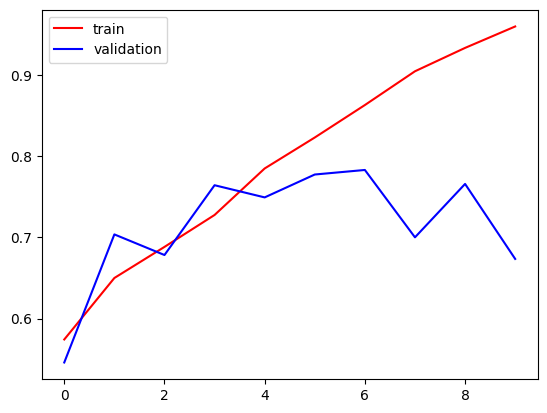

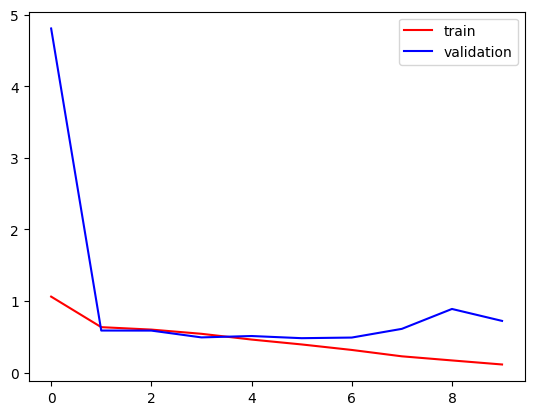

In [15]:
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

# Plot Training vs Validation Loss
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()